In [36]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test, create_dataloaders_train_val_test
import scipy.integrate
scipy.integrate.simps = scipy.integrate.simpson

%load_ext autoreload
%autoreload 2
%matplotlib inline



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
pp = Preprocessor()

In [38]:

df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [39]:
df_mrna_clean = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [40]:
Torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data)
X, durations, events , scaler = Torch_preprocessing.get_data_set()

Genes before Treshold: 503
count    503.000000
mean      67.017893
std      149.453685
min        0.000000
25%        0.000000
50%        0.000000
75%       12.000000
max      519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 459


In [ ]:
surival_data_set  = SurvivalDataSet(X, durations, events)
len(surival_data_set)

519

In [44]:
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_data_Train_Val_Test(surival_data_set)

Neural Net

In [45]:
in_features = train_X.shape[1]
num_nodes = [16, 16]
out_features = 1
batch_norm = True
dropout = 0.3
output_bias = False

net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, num_nodes=num_nodes, out_features=out_features, batch_norm=batch_norm,
    dropout=dropout, output_bias=output_bias
)

Training the Model

In [46]:
model = CoxPH(net, tt.torchtuples.optim.Adam)

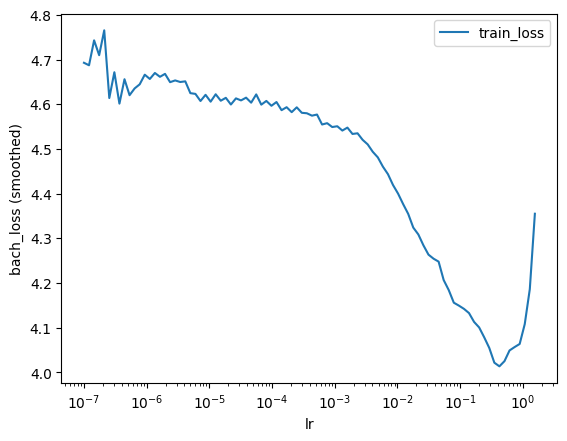

In [47]:
batch_size = 256
lrfinder = model.lr_finder(input=train_X,
                           target=(train_durations, train_events),
                           batch_size=batch_size,
                           tolerance=10)

_ = lrfinder.plot()

In [48]:
learning_rate = lrfinder.get_best_lr()
learning_rate

0.04229242874389523

In [54]:
model.optimizer.set_lr(learning_rate)

In [55]:
epochs = 200
callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=10)]
verbose = True

In [56]:
%%time
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

11:	[0s / 0s],		train_loss: 4.3105,	val_loss: 2.7700
12:	[0s / 0s],		train_loss: 3.8433,	val_loss: 3.9496
13:	[0s / 0s],		train_loss: 3.5706,	val_loss: 3.5797
14:	[0s / 0s],		train_loss: 3.1403,	val_loss: 3.5394
15:	[0s / 0s],		train_loss: 2.6494,	val_loss: 3.7713
16:	[0s / 0s],		train_loss: 2.3488,	val_loss: 4.1033
17:	[0s / 0s],		train_loss: 3.2326,	val_loss: 4.6538
18:	[0s / 0s],		train_loss: 2.4395,	val_loss: 5.3929
19:	[0s / 0s],		train_loss: 2.6412,	val_loss: 5.3287
20:	[0s / 0s],		train_loss: 1.9985,	val_loss: 4.7260
21:	[0s / 0s],		train_loss: 3.5392,	val_loss: 4.4150
CPU times: user 315 ms, sys: 10.4 ms, total: 325 ms
Wall time: 86.9 ms


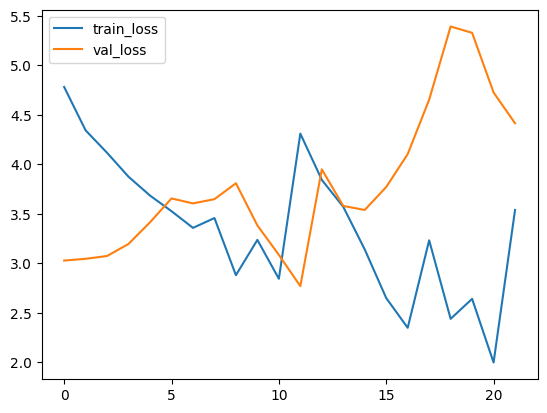

In [57]:
_ = log.plot()

In [58]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()

-2.7700062

In [59]:
log.to_pandas().val_loss.idxmin()

11

Prediction

In [18]:
_ = model.compute_baseline_hazards()

In [19]:
surv = model.predict_surv_df(input=test_X)

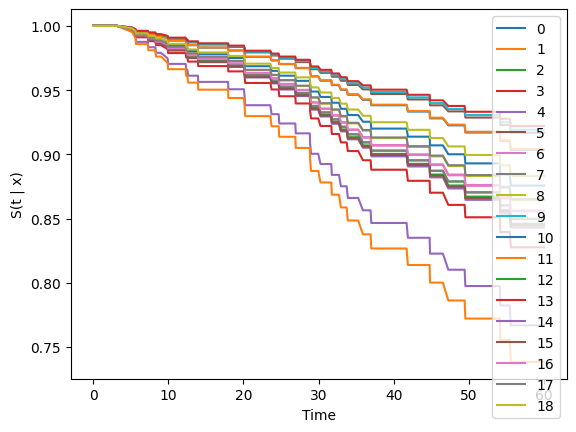

In [20]:
surv.iloc[:, :19].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel("Time")

Evaluation

In [21]:
test_durations = test_durations.cpu().detach().numpy()
test_events = test_events.cpu().detach().numpy()

In [22]:
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


In [ ]:
print(f"Concordance of the model {ev.concordance_td()}")


0.7222222222222222

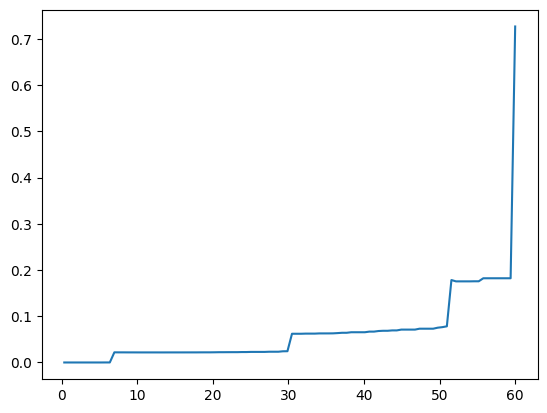

In [24]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [25]:
ev.integrated_brier_score(time_grid=time_grid)

0.06128905877197393

In [26]:
ev.integrated_nbll(time_grid)

0.22374826498473646